In [3]:
import pandas as pd

# Load file CSV yang sudah dibersihkan
df_msft = pd.read_csv('MSFT_cleaned.csv', parse_dates=['Date'])
df_nvda = pd.read_csv('NVDA_cleaned.csv', parse_dates=['Date'])



df_msft



,Date,Close Price,Highest Price,Lowest Price,Open Price,Trading Volume
0,2024-03-21,426.116760,427.555786,423.923513,426.573266,21296200
1,2024-03-22,425.491516,426.603025,422.841763,426.444264,17636500
2,2024-03-25,419.656067,424.171611,418.415538,422.018039,18060500
3,2024-03-26,418.455231,422.762344,418.157516,422.385218,16725600
4,2024-03-27,418.236908,421.234045,415.835261,421.224112,16705000
...,...,...,...,...,...,...
245,2025-03-14,388.559998,390.230011,379.510010,379.779999,19952800
246,2025-03-17,388.700012,392.709991,385.570007,386.700012,22474300
247,2025-03-18,383.519989,387.369995,381.100006,387.070007,19486900
248,2025-03-19,387.820007,389.679993,384.000000,385.529999,19185500


In [4]:
df_nvda

,Date,Close Price,Highest Price,Lowest Price,Open Price,Trading Volume
0,2024-03-21,91.404961,92.617567,90.375300,92.269682,480372000
1,2024-03-22,94.258026,94.746864,90.804159,91.111058,586719000
2,2024-03-25,94.970787,96.734207,93.479280,93.910139,552136000
3,2024-03-26,92.530586,96.343336,92.471608,95.819506,513648000
4,2024-03-27,90.220352,93.209368,89.093723,93.081411,586067000
...,...,...,...,...,...,...
245,2025-03-14,121.669998,121.879997,118.150002,118.610001,277593500
246,2025-03-17,119.529999,122.889999,118.029999,122.739998,255501500
247,2025-03-18,115.430000,119.019997,114.540001,118.000000,299686900
248,2025-03-19,117.519997,120.449997,115.680000,117.269997,273426200


In [7]:
print(df_msft.isnull().sum())
print('\n')
print(df_nvda.isnull().sum())


Date              0
Close Price       0
Highest Price     0
Lowest Price      0
Open Price        0
Trading Volume    0
dtype: int64


Date              0
Close Price       0
Highest Price     0
Lowest Price      0
Open Price        0
Trading Volume    0
dtype: int64


In [8]:
df_msft.sort_values('Date', inplace=True)
df_nvda.sort_values('Date', inplace=True)


In [9]:
df_msft.set_index('Date', inplace=True)
df_nvda.set_index('Date', inplace=True)


In [10]:
msft_close = df_msft[['Close Price']]
nvda_close = df_nvda[['Close Price']]


In [11]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
msft_scaled = scaler.fit_transform(msft_close)
nvda_scaled = scaler.fit_transform(nvda_close)


In [12]:
from sklearn.model_selection import train_test_split

# Misalnya kamu mau prediksi berdasarkan Close Price aja
X_msft = msft_scaled[:-1]       # Semua kecuali data terakhir
y_msft = msft_scaled[1:]        # Data target: nilai setelahnya (next day)

X_nvda = nvda_scaled[:-1]
y_nvda = nvda_scaled[1:]

# Split 80% training, 20% testing
X_train_msft, X_test_msft, y_train_msft, y_test_msft = train_test_split(
    X_msft, y_msft, test_size=0.2, shuffle=False)

X_train_nvda, X_test_nvda, y_train_nvda, y_test_nvda = train_test_split(
    X_nvda, y_nvda, test_size=0.2, shuffle=False)


In [13]:
print("📊 Jumlah data MSFT:")
print(f"  - Train: {len(X_train_msft)}")
print(f"  - Test : {len(X_test_msft)}\n")

print("📊 Jumlah data NVDA:")
print(f"  - Train: {len(X_train_nvda)}")
print(f"  - Test : {len(X_test_nvda)}")


📊 Jumlah data MSFT:
  - Train: 199
  - Test : 50

📊 Jumlah data NVDA:
  - Train: 199
  - Test : 50


In [14]:
from sklearn.linear_model import LinearRegression

# Inisialisasi model
model_msft = LinearRegression()
model_nvda = LinearRegression()

# Latih model
model_msft.fit(X_train_msft, y_train_msft)
model_nvda.fit(X_train_nvda, y_train_nvda)


LinearRegression()

In [15]:
# Prediksi
y_pred_msft = model_msft.predict(X_test_msft)
y_pred_nvda = model_nvda.predict(X_test_nvda)


📊 Evaluasi MSFT:
  - MAE  : 0.0573
  - MSE  : 0.0067
  - RMSE : 0.0817
  - R²   : 0.8495

📊 Evaluasi NVDA:
  - MAE  : 0.0559
  - MSE  : 0.0060
  - RMSE : 0.0777
  - R²   : 0.7023



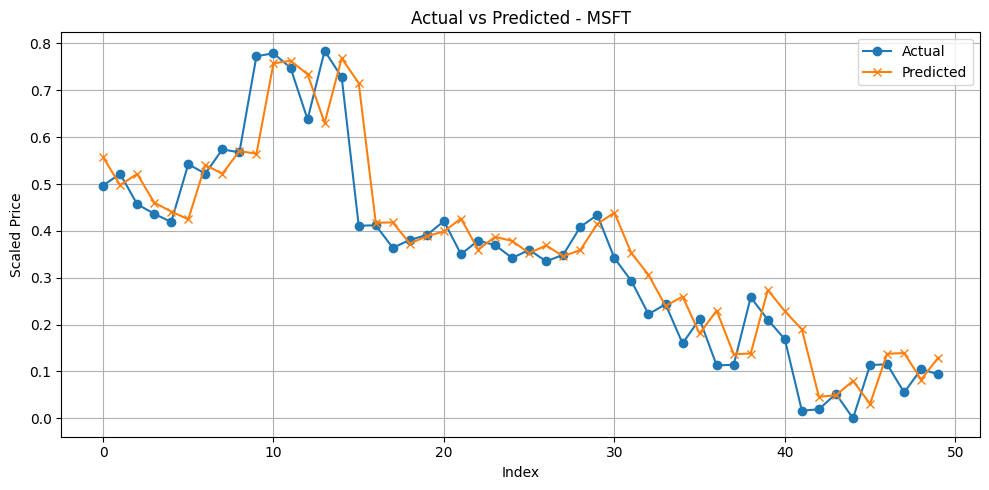

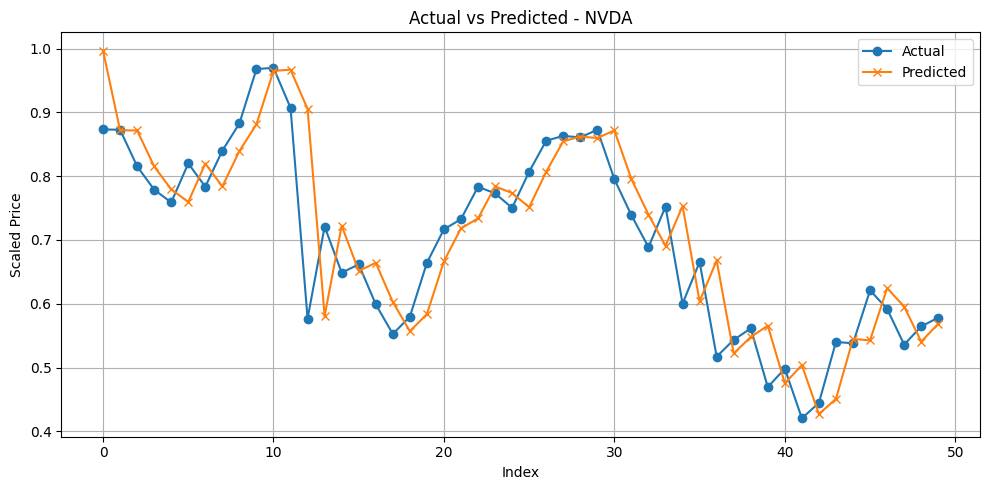

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 🔍 Fungsi Evaluasi
def evaluate_model(y_test, y_pred, label="Model"):
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print(f"📊 Evaluasi {label}:")
    print(f"  - MAE  : {mae:.4f}")
    print(f"  - MSE  : {mse:.4f}")
    print(f"  - RMSE : {rmse:.4f}")
    print(f"  - R²   : {r2:.4f}\n")

# Evaluasi MSFT dan NVDA
evaluate_model(y_test_msft, y_pred_msft, "MSFT")
evaluate_model(y_test_nvda, y_pred_nvda, "NVDA")

# 📈 Visualisasi Prediksi vs Asli
def plot_predictions(y_test, y_pred, title):
    plt.figure(figsize=(10, 5))
    plt.plot(y_test, label='Actual', marker='o')
    plt.plot(y_pred, label='Predicted', marker='x')
    plt.title(f'Actual vs Predicted - {title}')
    plt.xlabel('Index')
    plt.ylabel('Scaled Price')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_predictions(y_test_msft, y_pred_msft, 'MSFT')
plot_predictions(y_test_nvda, y_pred_nvda, 'NVDA')


Model Linear Regression lebih cocok untuk saham MSFT dibanding NVDA.
Model tersebut mampu menjelaskan 84.95% variasi harga MSFT, sedangkan hanya 70.23% untuk NVDA. Meskipun error rata-rata NVDA sedikit lebih kecil, kemampuan prediksi jangka panjang MSFT lebih unggul.